# Agglomerative Clustering from Scratch

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

## 1. Mock Data Generation

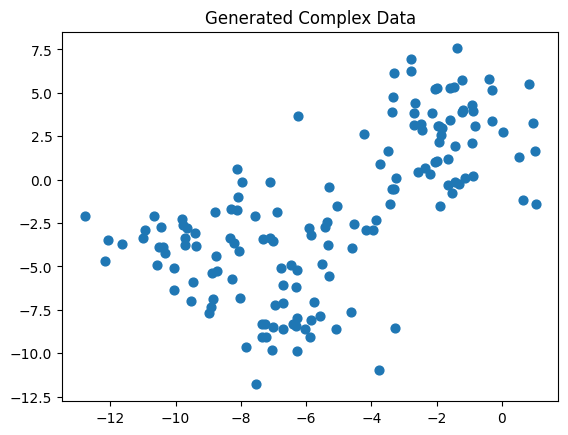

In [58]:
def get_complex_data():
    X, y = make_blobs(n_samples=150, centers=5, cluster_std=1.5, random_state=1)
    return X, y

X, y_true = get_complex_data()
plt.scatter(X[:, 0], X[:, 1], s=40)
plt.title("Generated Complex Data")
plt.show()

## 2. Implementation

In [62]:
class AgglomerativeSimple:
    def __init__(self, clusters=3):
        self.n_clusters = clusters

    def fit(self, X):
        # Initialize clusters as single points
        clusters = [[x] for x in X]
        
        while len(clusters) > self.n_clusters:
            min_dist = float('inf')
            pair = (0, 1)
            
            for i in range(len(clusters)):
                for j in range(i + 1, len(clusters)):
                    # Use single linkage distance (min distance between points in clusters)
                    d = min([np.linalg.norm(np.array(a) - np.array(b)) for a in clusters[i] for b in clusters[j]])
                    if d < min_dist:
                        min_dist = d
                        pair = (i, j)
            
            c1, c2 = pair
            clusters[c1].extend(clusters[c2])
            clusters.pop(c2)
        
        self.final_clusters = clusters
        # Create final labels array
        self.labels = np.zeros(len(X))
        for idx, cluster in enumerate(clusters):
            for pt in cluster:
                for orig_idx, orig_pt in enumerate(X):
                    if np.array_equal(pt, orig_pt):
                        self.labels[orig_idx] = idx
        return self

## 3. Training & Measurement

In [63]:
model = AgglomerativeSimple(clusters=3)
model.fit(X)

score = silhouette_score(X, model.labels)
print(f"Finished clustering. Silhouette Score: {score:.4f}")

Finished clustering. Silhouette Score: -0.1557


## 4. Visualization

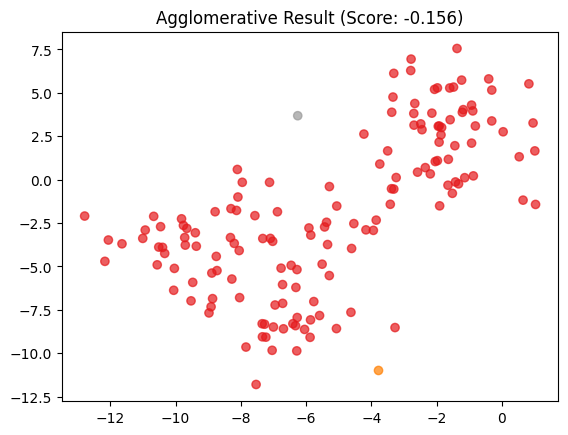

In [64]:
plt.scatter(X[:, 0], X[:, 1], c=model.labels, cmap='Set1', alpha=0.7)
plt.title(f"Agglomerative Result (Score: {score:.3f})")
plt.show()